<a href="https://colab.research.google.com/github/anirvinv/NeuralText/blob/master/SineFitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

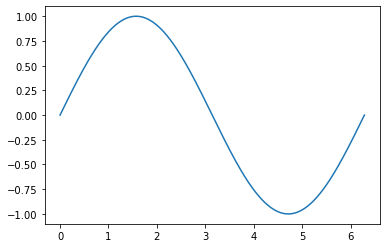

In [ ]:
import matplotlib.pyplot as plt 

X = np.linspace(0, 2*3.14159265, 300)
y = np.sin(X)

plt.plot(X, y)

In [ ]:
X = X.reshape(300,1)
y = y.reshape(300,1)

In [ ]:
class Dense_Layer:
  def __init__(self, n_neurons, n_features):
    self.weights = np.random.random((n_neurons, n_features))
    self.bias = np.random.random((n_neurons, 1))

  def forward(self, X):
    self.output = (np.dot(self.weights, X.T) + self.bias).T
    return self.output

class Activation:
  def __init__(self, s):
    if s == "sigm":
      self.f = self.sigmoid
    elif s == "relu":
      self.f = self.reLU
    else:
      raise Exception("Please pass in 'sigm' or 'relu' as parameters to constructor")
  def sigmoid(self, x, ):
    output = 1/(1 + np.exp(-1*x))
    return output

  def reLU(self, x):
    return np.maximum(0,x)
  def forward(self, X):
    self.output = self.f(X)
    return self.output
  

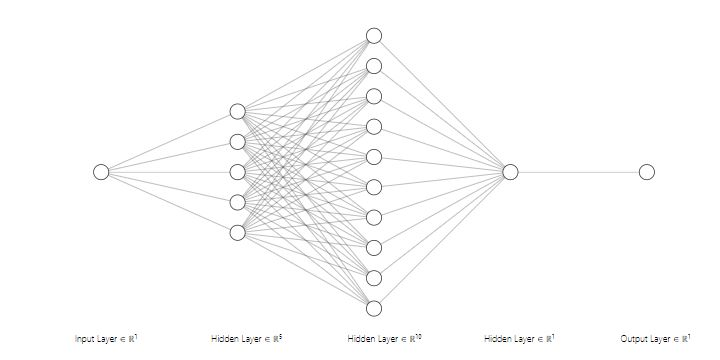

In [ ]:
np.random.seed(1)
def MSE(y1, y2):
  return np.sum((y1 - y2)**2)/y1.size

def LSE(y1, y2):
  return np.sum((y1 - y2)**2)


def reset_network():
  global l1, l2, l3, l4, act1, act2, act3 
  l1 = Dense_Layer(5, 1)
  l2 = Dense_Layer(10, 5)
  l3 = Dense_Layer(1, 10)
  l4 = Dense_Layer(1, 1)
  act1 = Activation('relu')
  act2 = Activation('relu')
  act3 = Activation('relu')

reset_network()

def neural_network(x):
  z1 = l1.forward(x)
  a1 = act1.forward(z1)

  z2 = l2.forward(a1)
  a2 = act2.forward(z2)


  z3 = l3.forward(a2)
  a3 = act3.forward(z3)

  z4 = l4.forward(a3)

  return x, z1, a1, z2, a2, z3, a3, z4 

x, z1, a1, z2, a2, z3, a3, z4 = neural_network(X)

In [ ]:
d_sigma = lambda z : np.cosh(z/2)**(-2) / 4

def d_relu(x):
  x1 = x.copy()
  x1[x1<=0] = 0
  x1[x1>0] = 1
  return x1

def sigmoid(x):
  return 1/(1 + np.exp(-x))

def relu(x):
  return np.maximum(0, x)


In [ ]:

def dJ_dW4(x, y):
  x, z1, a1, z2, a2, z3, a3, z4 = neural_network(x)
  #dJ_dz4 
  J = 2 * (z4 - y).T
  #dz4_dW4 
  J = J @ a3/x.size
  return J 


In [ ]:
dJ_dW4(X,y).shape == l4.weights.shape

True

In [ ]:

def dJ_db4(x,y):
  x, z1, a1, z2, a2, z3, a3, z4 = neural_network(x)
  #dJ_dz4
  J = 2 * (z4 - y).T
  #dz4_db4
  J = (np.sum(J, axis = 1)/x.size).reshape(1,1)
  return J


In [ ]:
dJ_db4(X,y).shape == l4.bias.shape

True

In [ ]:

def dJ_dW3(x, y):  
  x, z1, a1, z2, a2, z3, a3, z4 = neural_network(x)

  #dJ_dz4 
  J = 2 * (z4 - y)
  
  # dz4_da3 
  J = np.dot(J, l4.weights)
  #da3_dz3 
  # J = J * d_sigma(z3)
  J = J * d_relu(z3)

  #dz3_dW3  
  J = (J.T @ a2)/x.size
  
  return J



In [ ]:
dJ_dW3(X, y).shape == l3.weights.shape

True

In [ ]:
def dJ_db3(x, y):  
  x, z1, a1, z2, a2, z3, a3, z4 = neural_network(x)

  #dJ_dz4 
  J = 2 * (z4 - y)
  
  # dz4_da3 
  J = np.dot(J, l4.weights)
  #da3_dz3 
  # J = J * d_sigma(z3)
  J = J * d_relu(z3)

  #dz3_dW3  
  J = (np.sum(J, axis=0)/x.size).reshape(1,1) 
  return J
  


In [ ]:
dJ_db3(X,y).shape == l3.bias.shape

True

In [ ]:
def dJ_dW2(x, y):  
  x, z1, a1, z2, a2, z3, a3, z4 = neural_network(x)
  #dJ_dz4 
  J = 2 * (z4 - y)
  
  # dz4_da3 
  J = np.dot(J, l4.weights.T)
  #da3_dz3 
  # J = J * d_sigma(z3)
  J = J * d_relu(z3)
  
  
  #dz3_da2  
  J = np.dot(J, l3.weights)
  #da2_dz2
  # J = J * d_sigma(z2)
  J = J*d_relu(z2)

  #dz2_dW2
  J = np.dot(J.T, a1)/x.size
  
  return J


In [ ]:
dJ_dW2(X,y).shape == l2.weights.shape

True

In [ ]:
def dJ_db2(x, y):  
  x, z1, a1, z2, a2, z3, a3, z4 = neural_network(x)
  J = 2 * (z4 - y)
  
  # dz4_da3 
  J = np.dot(J, l4.weights.T)
  #da3_dz3 
  # J = J * d_sigma(z3)
  J = J * d_relu(z3)
  
  
  #dz3_da2  
  J = np.dot(J, l3.weights)
  #da2_dz2
  # J = J * d_sigma(z2)
  J = J * d_relu(z2)

  #dz2_db2d
  J = (np.sum(J, axis=0)/x.size).reshape(10,1)
  return J

In [ ]:
dJ_db2(X,y).shape == l2.bias.shape

True

In [ ]:
def dJ_dW1(x, y):  
  x, z1, a1, z2, a2, z3, a3, z4 = neural_network(x)
  #dJ_dz4 
  J = 2 * (z4 - y)
  
  # dz4_da3 
  J = np.dot(J, l4.weights.T)
  #da3_dz3 
  # J = J * d_sigma(z3)
  J = J * d_relu(z3)
  
  
  #dz3_da2  
  J = np.dot(J, l3.weights)
  #da2_dz2
  # J = J * d_sigma(z2)
  J = J * d_relu(z2)

  #dz2_da1
  J = np.dot(J, l2.weights)

  #da1_dW1
  J = np.dot(J.T, x)/x.size
  
  return J

In [ ]:
dJ_dW1(X,y).shape == l1.weights.shape

True

In [ ]:
def dJ_db1(x, y):  
  x, z1, a1, z2, a2, z3, a3, z4 = neural_network(x)
  #dJ_dz4 
  J = 2 * (z4 - y)
  
  # dz4_da3 
  J = np.dot(J, l4.weights.T)
  #da3_dz3 
  # J = J * d_sigma(z3)
  J = J * d_relu(z3)
  
  
  #dz3_da2  
  J = np.dot(J, l3.weights)
  #da2_dz2
  # J = J * d_sigma(z2)
  J = J * d_relu(z2)

  #dz2_da1
  J = np.dot(J, l2.weights)

  #da1_db1
  J = (np.sum(J, axis =0)/x.size).reshape(5,1)
  return J

In [ ]:
dJ_db1(X,y).shape == l1.bias.shape

True

Back Propogation Time

In [ ]:
def backpropogation(epochs = 1000, lr = .1):
  for i in range(epochs):
    l4.weights -= dJ_dW4(X, y) * lr  
    l4.bias -= dJ_db4(X, y) * lr

    l3.weights -= dJ_dW3(X, y) * lr  
    l3.bias -= dJ_db3(X, y) * lr

    l2.weights -= dJ_dW2(X, y) * lr
    l2.bias -= dJ_db2(X,y) * lr

    l1.weights -= dJ_dW1(X,y) * lr
    l1.bias -= dJ_db1(X,y) * lr

    # if i % 100 == 0:
    #   print(l4.weights)
    #   print(l4.bias)

In [ ]:
reset_network()
x, z1, a1, z2, a2, z3, a3, z4  = neural_network(X)
MSE(z4, y),LSE(z4, y)

(317.5273352560218, 95258.20057680654)

In [ ]:
backpropogation()
x, z1, a1, z2, a2, z3, a3, z4  = neural_network(X)
MSE(z4, y), LSE(z4, y)

(0.4983333339026784, 149.50000017080353)

In [1022]:
z4.ravel()

array([-1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -1.19660125e-11, -1.19660125e-11, -1.19660125e-11,
       -1.19660125e-11, -

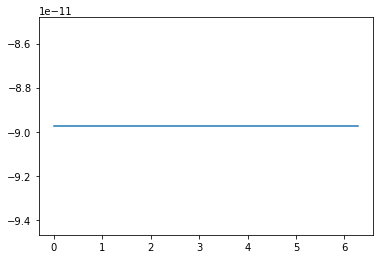

In [ ]:
plt.plot(X, z4)

In [ ]:
bruh = np.array([[1],
                 [2],
                 [3],
                 [4]])

weight = np.array([[10.0],
                   ])

out = np.array([[2],
              [4],
              [6],
              [8]])

z1 = bruh.dot(weight.T)

a1 = relu(z1)

print("MSE error:", MSE(y, a1),"LSE error:" ,LSE(y, a1))

for i in range(2000):
  a1 = relu(bruh.dot(weight.T))

  #dJ_da1
  J = 2 * (a1 - out)
  
  #da1_dz1
  J = J * d_relu(z1)
  
  #dz1_dw
  J = np.dot(J.T, bruh).T

  weight -= J * 0.001
  
  

MSE error: 480.0 LSE error: 1920.0


In [ ]:
a1 = relu(bruh.dot(weight.T))
print("output:\n",a1)
print("MSE error:", MSE(y, a1),"LSE error:" ,LSE(y, a1))
print(weight)

output:
 [[2.]
 [4.]
 [6.]
 [8.]]
MSE error: 9.466330862652142e-29 LSE error: 3.7865323450608567e-28
[[2.]]
